## Rate Limiting

A rate limiter controls how many requests a client can make within a specfic timeframe.
It acts like a traffic controller for your APIs - allowing 100 request/second from a user, then rejecting excess requests with an HTTP 429 "Too many requests" response. 
Rate limiters prevents:
1. Prevents abuse or resource starvation caused by Denial of Service (DoS) attack.
2. Reduce cost. Limiting the number of calls is essential to reduce cost.
3. Prevent server from being overloaded. To reduce server load caused by excess use caused by bots or users misbehaviour.

### Where should we keep the rate limiter:
1. Client side implementation: We may not have control over client implementation and client requests can be easily forged.
2. Server side Implementation: rate limiter kept on servers, but that requires rate limiters mismatch and sync issue as number of servers get increased.
3. MiddleWare: rate limiting is usually implemented within component called API Gateway. API Gateway is a fully managed service which supports rate limiting, SSL termination, authentication, IP Whitelisting, servicing static content etc..

Building a rate limiter service takes time. So, if you do not have a enough engineeing resources to implement a rate limiter, a commercial API gateway is a better option. 

### Algorithms of Rate limiting

There are five rate limiting algorithms:
1. Token Bucket
2. Leaking Bucket
3. Fixed Window Counter
4. Sliding Window log
5. Sliding Window Context.

Ref: https://blog.algomaster.io/p/rate-limiting-algorithms-explained-with-code

#### Token Bucket Algorithm
A token bucket is a container that has pre-defined capacity. Tokens are put into the bucket at preset rates periodically. Once the bucket is full, no more tokens are added. The refiller puts 2 tokens every second. Once the bucket is full, extra tokens will overflow.
Each request consumes a token. When a request arrives, we check if there are enough tokens in the bucket.if
-> There are enough tokens, we take one token out of each request, and request goes through.
-> If there are not enough tokens, the request is dropped. 

##### Token bucket algorithm takes two parameters:
1. Bucket size: the maximum number of tokens allowed in the bucket.
2. Refill rate : Number of tokens put into bucket each second.

It is challenging to tune above parameters them properly, by use metrics and monitoring relax the rules little bit.

Number of Buckets needed is based on the rate limiting rules:
1. It is better to have different bucket for different APIs like if user allowed to make 1 post per second, add 150 friends per day and like 5 posts per second -> we need 3 buckets are required per user.
2. If we need to throttle a request based on IP address, each IP address requires a bucket.
3. If you allow maximum of 10000 requests per second, it make sense to have a global bucket shared by all request.

* When bucket_size > refill_rate, the behaviors diverge significantly — Token Bucket is deliberately more permissive to absorb legitimate traffic spikes.

* So bucket_size only buys you one free burst after a long idle period. It doesn't change what the long-term rate is — that's always refill_rate. If your traffic is consistently bursty with short gaps (like your 0.5s gap), bucket_size gives you almost nothing and the effective limit converges to refill_rate.

In [ ]:
import time

class TokenBucket:
    """
    Token Bucket rate limiter.

    Tokens accumulate at `refill_rate` per second up to `bucket_size`.
    Each allowed request consumes one token. Requests are rejected when
    the bucket is empty.
    """

    def __init__(self, bucket_size: int, refill_rate: float):
        """
        :param bucket_size:  Maximum number of tokens the bucket can hold.
        :param refill_rate:  Tokens added per second.
        """
        self.bucket_size = bucket_size
        self.refill_rate = refill_rate
        # Per-client state: {client_id -> {"tokens": float, "last_refill": float}}
        self._buckets: dict[str, dict] = {}

    def _get_bucket(self, client_id: str) -> dict:
        if client_id not in self._buckets:
            self._buckets[client_id] = {
                # The float matters: tokens are stored as float, not int. 
                # A request at t=0.3s adds 0.6 tokens (not rounded to 0). 
                # That fractional credit accumulates, so after ~1.67 requests' worth of time the client 
                # earns a full token. This makes the algorithm fair at sub-second granularity.
                "tokens": float(self.bucket_size),
                "last_refill": time.monotonic(),
            }
        return self._buckets[client_id]

    def _refill(self, bucket: dict) -> None:
        now = time.monotonic()
        elapsed = now - bucket["last_refill"]
        new_tokens = elapsed * self.refill_rate
        bucket["tokens"] = min(self.bucket_size, bucket["tokens"] + new_tokens)
        bucket["last_refill"] = now

    def allow_request(self, client_id: str) -> bool:
        """
        Returns True if the request is allowed (token consumed),
        False if the bucket is empty (request should be rejected with 429).
        """
        bucket = self._get_bucket(client_id)
        self._refill(bucket)

        if bucket["tokens"] >= 1:
            bucket["tokens"] -= 1
            return True
        return False


# ---------------------------------------------------------------------------
# Demo
# ---------------------------------------------------------------------------
limiter = TokenBucket(bucket_size=5, refill_rate=2)  # 5 tokens max, 2/sec

print("--- Burst of 7 requests (bucket starts full at 5) ---")
for i in range(7):
    allowed = limiter.allow_request("user-1")
    print(f"  Request {i + 1}: {'ALLOWED' if allowed else 'REJECTED (429)'}")

print("\n--- Wait 1 second (expect ~2 new tokens) ---")
time.sleep(1)
for i in range(3):
    allowed = limiter.allow_request("user-1")
    print(f"  Request {i + 1}: {'ALLOWED' if allowed else 'REJECTED (429)'}")


### Leaking Bucket Algorithm
Leaking bucket algorithm is similar to token bucket except that requests are processed at fixed rate. It is usually implemented in FIFO queue. The algorithm works as follows:
1. When a request arrives, the system checks if the queue is full, if it is not full, the request is added to the queue.
2. Otherwise the request is dropped.
3. Requests are pulled from the queue and processed at regular intervals.

Leaking bucket algorithm takes following two parameters:
1. Bucket size: equals to queue size. Queues holds the request to be processed at fixed rate.
2. Outflow rate: It defines how many requests can be processes at a fixed rate, usually in seconds.

Cons: 
1. Burst of traffic fills up the queu with old request and if they are not processed in time, recent requests will be rate limited.
2. There are two parameters in algorithm, which is not easy to tune them properly.

In [4]:
import time
from collections import deque
from threading import Lock


class LeakingBucket:
    """
    Leaking Bucket rate limiter.

    Incoming requests queue up in a FIFO queue (the "bucket").
    A background-style processor drains the queue at a fixed `outflow_rate`.
    Requests are rejected immediately when the queue is full.

    Key difference from Token Bucket:
      - Token Bucket: allows bursts up to bucket_size, output rate varies.
      - Leaking Bucket: output is always smooth at outflow_rate, bursts are queued then shed.
    """

    def __init__(self, bucket_size: int, outflow_rate: float):
        """
        :param bucket_size:   Max number of requests that can wait in the queue.
        :param outflow_rate:  Requests processed per second (steady outflow).
        """
        self.bucket_size = bucket_size
        self.outflow_rate = outflow_rate          # requests / second
        self._interval = 1.0 / outflow_rate       # seconds between each processed request

        # Per-client state: {client_id -> {"queue": deque, "last_processed": float}}
        self._clients: dict[str, dict] = {}
        self._lock = Lock()

    def _get_state(self, client_id: str) -> dict:
        if client_id not in self._clients:
            print(f"Client {client_id} created a monotonic time is {time.monotonic()}")
            self._clients[client_id] = {
                "queue": deque(),
                "last_processed": time.monotonic(),
            }
        return self._clients[client_id]

    def _drain(self, state: dict) -> None:
        """
        Simulate the leak: remove requests that would have been processed
        by now based on elapsed time and outflow_rate.
        """
        now = time.monotonic()
        elapsed = now - state["last_processed"]
        
        processed_count = int(elapsed / self._interval)
        print(f"Elaspsed time is {elapsed} and processed count is {processed_count}")
        if processed_count > 0:
            for _ in range(min(processed_count, len(state["queue"]))):
                state["queue"].popleft()
            state["last_processed"] = now

    def allow_request(self, client_id: str) -> bool:
        """
        Returns True if the request was queued (will be processed),
        False if the queue is full (request is dropped → 429).
        """
        with self._lock:
            state = self._get_state(client_id)
            self._drain(state)

            if len(state["queue"]) < self.bucket_size:
                state["queue"].append(time.monotonic())
                return True
            return False

    def queue_length(self, client_id: str) -> int:
        with self._lock:
            state = self._get_state(client_id)
            self._drain(state)
            return len(state["queue"])


# ---------------------------------------------------------------------------
# Demo
# ---------------------------------------------------------------------------
limiter = LeakingBucket(bucket_size=5, outflow_rate=2)  # queue=5, process 2/sec

print("--- Burst of 8 requests (queue capacity is 5) ---")
for i in range(8):
    allowed = limiter.allow_request("user-1")
    print(f"  Request {i + 1}: {'QUEUED' if allowed else 'DROPPED (429)'}")

print(f"\n  Queue length: {limiter.queue_length('user-1')}")

print("\n--- Wait 2 seconds (2/sec drains ~4 requests) ---")
time.sleep(2)
print(f"  Queue length after 2s: {limiter.queue_length('user-1')}")

print("\n--- Send 3 more requests ---")
for i in range(3):
    allowed = limiter.allow_request("user-1")
    print(f"  Request {i + 1}: {'QUEUED' if allowed else 'DROPPED (429)'}")


--- Burst of 8 requests (queue capacity is 5) ---
Client user-1 created a monotonic time is 117073.559590791
Elaspsed time is 1.334003172814846e-06 and processed count is 0
  Request 1: QUEUED
Elaspsed time is 2.9417002224363387e-05 and processed count is 0
  Request 2: QUEUED
Elaspsed time is 4.354199336376041e-05 and processed count is 0
  Request 3: QUEUED
Elaspsed time is 5.51249977434054e-05 and processed count is 0
  Request 4: QUEUED
Elaspsed time is 6.608400144614279e-05 and processed count is 0
  Request 5: QUEUED
Elaspsed time is 8.258399611804634e-05 and processed count is 0
  Request 6: DROPPED (429)
Elaspsed time is 9.395899542141706e-05 and processed count is 0
  Request 7: DROPPED (429)
Elaspsed time is 0.00010408399975858629 and processed count is 0
  Request 8: DROPPED (429)
Elaspsed time is 0.0001425420050509274 and processed count is 0

  Queue length: 5

--- Wait 2 seconds (2/sec drains ~4 requests) ---
Elaspsed time is 2.005215750003117 and processed count is 4
  Q

### Fixed Window Counter Algorithm
Fixed window divides the timeline into fixed sized time windows, and assign counters to each window. Each request increments the counter by one. Once the counter reaches the pre-defined threshold, new requests are dropped until a new time window starts.

The major problem is spike in traffic at edge of a window could cause more requests than allowed quota to go through.


In [5]:
import time
from threading import Lock


class FixedWindowCounter:
    """
    Fixed Window Counter rate limiter.

    The timeline is divided into fixed-size windows (e.g. each 1 second).
    Every request increments the counter for the current window.
    Once the counter hits the limit, requests are rejected until the next window starts.

    Known weakness: a burst at the END of window N and START of window N+1
    can allow up to 2x the limit within a short period.

    Example with limit=5, window=1s:
        t=0.9s  → 5 requests allowed  (window 0, counter=5)
        t=1.1s  → 5 requests allowed  (window 1, counter=5)
        → 10 requests passed in just 0.2 seconds
    """

    def __init__(self, limit: int, window_size: float = 1.0):
        """
        :param limit:        Max requests allowed per window.
        :param window_size:  Duration of each window in seconds.
        """
        self.limit = limit
        self.window_size = window_size
        # Per-client state: {client_id -> {"count": int, "window_start": float}}
        self._clients: dict[str, dict] = {}
        self._lock = Lock()

    def _current_window(self) -> float:
        """Returns the start timestamp of the window the current moment belongs to."""
        now = time.monotonic()
        return now - (now % self.window_size)

    def _get_state(self, client_id: str) -> dict:
        if client_id not in self._clients:
            self._clients[client_id] = {
                "count": 0,
                "window_start": self._current_window(),
            }
        return self._clients[client_id]

    def allow_request(self, client_id: str) -> bool:
        """
        Returns True if the request is within the limit for the current window,
        False if the limit is exceeded (request should be rejected with 429).
        """
        with self._lock:
            state = self._get_state(client_id)
            current_window = self._current_window()

            # New window started — reset the counter
            if current_window > state["window_start"]:
                state["count"] = 0
                state["window_start"] = current_window

            if state["count"] < self.limit:
                state["count"] += 1
                return True
            return False

    def current_count(self, client_id: str) -> int:
        with self._lock:
            return self._get_state(client_id)["count"]


# ---------------------------------------------------------------------------
# Demo
# ---------------------------------------------------------------------------
limiter = FixedWindowCounter(limit=5, window_size=1.0)  # 5 requests per second

print("--- Burst of 7 requests in window 1 ---")
for i in range(7):
    allowed = limiter.allow_request("user-1")
    print(f"  Request {i + 1}: {'ALLOWED' if allowed else 'REJECTED (429)'}")

print(f"\n  Counter: {limiter.current_count('user-1')}/5")

print("\n--- Wait for next window ---")
time.sleep(1.0)

print("\n--- 7 more requests in window 2 ---")
for i in range(7):
    allowed = limiter.allow_request("user-1")
    print(f"  Request {i + 1}: {'ALLOWED' if allowed else 'REJECTED (429)'}")

# ---------------------------------------------------------------------------
# Demonstrate the boundary spike weakness
# ---------------------------------------------------------------------------
print("\n--- Boundary spike: 5 requests at end of window, 5 at start of next ---")
limiter2 = FixedWindowCounter(limit=5, window_size=1.0)

# Burn the current window first to align cleanly to the boundary
now = time.monotonic()
sleep_to_boundary = limiter2.window_size - (now % limiter2.window_size) - 0.05
time.sleep(max(sleep_to_boundary, 0))

for i in range(5):
    limiter2.allow_request("user-2")
print(f"  Last 0.05s of window: 5 requests sent (counter={limiter2.current_count('user-2')})")

time.sleep(0.1)  # cross into the next window

for i in range(5):
    allowed = limiter2.allow_request("user-2")
print(f"  First 0.05s of new window: 5 requests sent (counter={limiter2.current_count('user-2')})")
print("  → 10 requests passed in ~0.1 seconds — the boundary spike problem")


--- Burst of 7 requests in window 1 ---
  Request 1: ALLOWED
  Request 2: ALLOWED
  Request 3: ALLOWED
  Request 4: ALLOWED
  Request 5: ALLOWED
  Request 6: REJECTED (429)
  Request 7: REJECTED (429)

  Counter: 5/5

--- Wait for next window ---

--- 7 more requests in window 2 ---
  Request 1: ALLOWED
  Request 2: ALLOWED
  Request 3: ALLOWED
  Request 4: ALLOWED
  Request 5: ALLOWED
  Request 6: REJECTED (429)
  Request 7: REJECTED (429)

--- Boundary spike: 5 requests at end of window, 5 at start of next ---
  Last 0.05s of window: 5 requests sent (counter=5)
  First 0.05s of new window: 5 requests sent (counter=5)
  → 10 requests passed in ~0.1 seconds — the boundary spike problem


### Sliding Window Log Algorithm

Instead of resetting a counter at fixed boundaries, the Sliding Window Log keeps a log of timestamps for every request. On each new request, it evicts timestamps older than `now - window_size` and checks how many remain.

**Parameters:**
1. `limit` — max requests allowed within the window.
2. `window_size` — rolling duration in seconds (e.g. 1.0 = last 1 second).

**Pros:**
- No boundary spike — the window rolls with time, so there is no reset edge to exploit.
- Accurate to the exact request timestamp.

**Cons:**
- Memory cost — every request timestamp is stored, even rejected ones.
  With a high limit (e.g. 10,000 req/sec x many clients), the log can grow large.
- Sliding Window Counter (next) trades some accuracy for much lower memory usage.


In [ ]:
import time
from collections import deque
from threading import Lock


class SlidingWindowLog:
    """
    Sliding Window Log rate limiter.

    Maintains a deque of request timestamps per client.
    On every request:
      1. Evict timestamps older than (now - window_size)  ← the "slide"
      2. If len(log) < limit → allow and append timestamp
         Else                → reject (429)

    Unlike Fixed Window, the window is anchored to NOW, not to a clock boundary.
    A burst at t=0.9s and t=1.1s cannot exploit a reset — both timestamps
    are visible as long as they fall within the same rolling window.
    """

    def __init__(self, limit: int, window_size: float = 1.0):
        """
        :param limit:        Max requests allowed in any rolling window_size period.
        :param window_size:  Width of the rolling window in seconds.
        """
        self.limit = limit
        self.window_size = window_size
        # Per-client state: {client_id -> deque of accepted timestamps}
        self._logs: dict[str, deque] = {}
        self._lock = Lock()

    def _get_log(self, client_id: str) -> deque:
        if client_id not in self._logs:
            self._logs[client_id] = deque()
        return self._logs[client_id]

    def _evict(self, log: deque, now: float) -> None:
        """Remove timestamps that have fallen outside the rolling window."""
        cutoff = now - self.window_size
        while log and log[0] <= cutoff:
            log.popleft()

    def allow_request(self, client_id: str) -> bool:
        """
        Returns True if the request is within the limit,
        False if the rolling window is full (429).
        """
        with self._lock:
            now = time.monotonic()
            log = self._get_log(client_id)
            self._evict(log, now)

            if len(log) < self.limit:
                log.append(now)
                return True
            return False

    def current_count(self, client_id: str) -> int:
        """Number of requests currently inside the rolling window."""
        with self._lock:
            now = time.monotonic()
            log = self._get_log(client_id)
            self._evict(log, now)
            return len(log)


# ---------------------------------------------------------------------------
# Demo 1: basic burst behaviour
# ---------------------------------------------------------------------------
limiter = SlidingWindowLog(limit=5, window_size=1.0)

print("--- Burst of 7 requests ---")
for i in range(7):
    allowed = limiter.allow_request("user-1")
    print(f"  Request {i + 1}: {'ALLOWED' if allowed else 'REJECTED (429)'}")

print(f"\n  Window count: {limiter.current_count('user-1')}/5")

print("\n--- Wait 1 second (all prior timestamps evicted) ---")
time.sleep(1.0)
print(f"  Window count after 1s: {limiter.current_count('user-1')}/5")

print("\n--- 3 new requests ---")
for i in range(3):
    allowed = limiter.allow_request("user-1")
    print(f"  Request {i + 1}: {'ALLOWED' if allowed else 'REJECTED (429)'}")

# ---------------------------------------------------------------------------
# Demo 2: boundary spike comparison vs Fixed Window
# ---------------------------------------------------------------------------
print("\n--- Boundary spike test (exploits Fixed Window, blocked here) ---")
limiter2 = SlidingWindowLog(limit=5, window_size=1.0)

# Send 5 requests near the end of a "virtual" second
for _ in range(5):
    limiter2.allow_request("user-2")
print(f"  First 5 requests: all allowed  (window={limiter2.current_count('user-2')})")

# Wait a tiny bit — in Fixed Window the counter would reset; here the log still holds them
time.sleep(0.1)
results = [limiter2.allow_request("user-2") for _ in range(5)]
allowed_count = sum(results)
print(f"  Next 5 requests 0.1s later: {allowed_count} allowed, {5 - allowed_count} rejected")
print(f"  Window count: {limiter2.current_count('user-2')}/5")
print("  → No boundary spike: old timestamps still in the window")


### Sliding Window Counter Algorithm

Sliding Window Counter is a memory-efficient approximation of Sliding Window Log.
Instead of storing every timestamp, it keeps only **two integers** — the counter for
the previous window and the counter for the current window — and estimates how many
requests fall inside the rolling window using a weighted sum.

```
rolling_count = prev_count * (1 - elapsed_fraction) + curr_count
```

Where `elapsed_fraction` is how far into the current window we are (0.0 → 1.0).

**Example** (limit=10, window=1s):
- Previous window had 8 requests.
- We are 0.3s into the current window (elapsed_fraction=0.3).
- Current window so far has 3 requests.
- Estimated rolling count = 8 x (1 - 0.3) + 3 = 5.6 + 3 = 8.6 → under limit

**Pros:**
- O(1) memory per client — only two counters, regardless of limit size.
- Smooths out the boundary spike like Sliding Window Log.

**Cons:**
- Approximate — assumes requests in the previous window were evenly distributed.
  In reality they may have been clustered, so the estimate can be slightly off.
- Not suitable when strict per-request accuracy is required.


In [ ]:
import time
from threading import Lock


class SlidingWindowCounter:
    """
    Sliding Window Counter rate limiter.

    Keeps two counters per client: prev_count and curr_count.
    On every request it computes an estimated rolling count:

        rolling = prev_count * (1 - elapsed_fraction) + curr_count

    where elapsed_fraction = how far into the current window we are (0.0–1.0).

    This approximates Sliding Window Log at O(1) memory per client.
    """

    def __init__(self, limit: int, window_size: float = 1.0):
        """
        :param limit:        Max requests allowed in any rolling window_size period.
        :param window_size:  Width of each fixed window in seconds.
        """
        self.limit = limit
        self.window_size = window_size
        # Per-client state dict
        self._clients: dict[str, dict] = {}
        self._lock = Lock()

    def _current_window_start(self) -> float:
        """Snap current time down to the nearest window boundary."""
        now = time.monotonic()
        return now - (now % self.window_size)

    def _get_state(self, client_id: str) -> dict:
        if client_id not in self._clients:
            self._clients[client_id] = {
                "prev_count": 0,
                "curr_count": 0,
                "window_start": self._current_window_start(),
            }
        return self._clients[client_id]

    def _maybe_roll_window(self, state: dict, window_start: float) -> None:
        """
        Advance the window if time has moved past the current boundary.

        Two cases:
          1. Exactly one window has passed → prev = curr, curr = 0
          2. Two or more windows have passed → both counters reset to 0
             (no prior traffic is relevant anymore)
        """
        windows_elapsed = int(
            (window_start - state["window_start"]) / self.window_size
        )
        if windows_elapsed == 1:
            state["prev_count"] = state["curr_count"]
            state["curr_count"] = 0
        elif windows_elapsed > 1:
            state["prev_count"] = 0
            state["curr_count"] = 0
        state["window_start"] = window_start

    def _rolling_count(self, state: dict, now: float) -> float:
        """
        Weighted estimate of requests in the last window_size seconds.

        elapsed_fraction: how far into the current window we are.
        The complement (1 - elapsed_fraction) is the portion of the previous
        window still inside the rolling view.
        """
        elapsed_fraction = (now - state["window_start"]) / self.window_size
        return state["prev_count"] * (1 - elapsed_fraction) + state["curr_count"]

    def allow_request(self, client_id: str) -> bool:
        """
        Returns True if the estimated rolling count is under the limit,
        False otherwise (429).
        """
        with self._lock:
            now = time.monotonic()
            window_start = self._current_window_start()
            state = self._get_state(client_id)

            self._maybe_roll_window(state, window_start)

            if self._rolling_count(state, now) < self.limit:
                state["curr_count"] += 1
                return True
            return False

    def rolling_count(self, client_id: str) -> float:
        """Current estimated rolling count (for inspection)."""
        with self._lock:
            now = time.monotonic()
            state = self._get_state(client_id)
            self._maybe_roll_window(state, self._current_window_start())
            return self._rolling_count(state, now)


# ---------------------------------------------------------------------------
# Demo 1: basic limiting
# ---------------------------------------------------------------------------
limiter = SlidingWindowCounter(limit=5, window_size=1.0)

print("--- Burst of 7 requests ---")
for i in range(7):
    allowed = limiter.allow_request("user-1")
    print(f"  Request {i + 1}: {'ALLOWED' if allowed else 'REJECTED (429)'}"
          f"  (rolling={limiter.rolling_count('user-1'):.2f})")

print("\n--- Wait 1 second ---")
time.sleep(1.0)
print(f"  Rolling count after 1s: {limiter.rolling_count('user-1'):.2f}")

print("\n--- 3 new requests ---")
for i in range(3):
    allowed = limiter.allow_request("user-1")
    print(f"  Request {i + 1}: {'ALLOWED' if allowed else 'REJECTED (429)'}"
          f"  (rolling={limiter.rolling_count('user-1'):.2f})")

# ---------------------------------------------------------------------------
# Demo 2: boundary spike comparison
# ---------------------------------------------------------------------------
print("\n--- Boundary spike test ---")
limiter2 = SlidingWindowCounter(limit=5, window_size=1.0)

for _ in range(5):
    limiter2.allow_request("user-2")
print(f"  First 5 requests: all allowed (rolling={limiter2.rolling_count('user-2'):.2f})")

time.sleep(0.1)   # cross into a new window — Fixed Window would reset here
results = [limiter2.allow_request("user-2") for _ in range(5)]
allowed_count = sum(results)
print(f"  Next 5 requests 0.1s later: {allowed_count} allowed, {5 - allowed_count} rejected")
print(f"  Rolling count: {limiter2.rolling_count('user-2'):.2f}/5")
print("  → Boundary spike dampened by the weighted prev_count")

# ---------------------------------------------------------------------------
# Demo 3: side-by-side memory comparison
# ---------------------------------------------------------------------------
print("\n--- Memory: Sliding Window Log vs Counter (limit=10,000) ---")
print(f"  Log:     stores up to 10,000 timestamps per client  → O(limit)")
print(f"  Counter: stores 3 integers per client               → O(1)")


![Screenshot 2026-04-15 at 11.06.20 AM.png](<attachment:Screenshot 2026-04-15 at 11.06.20 AM.png>)
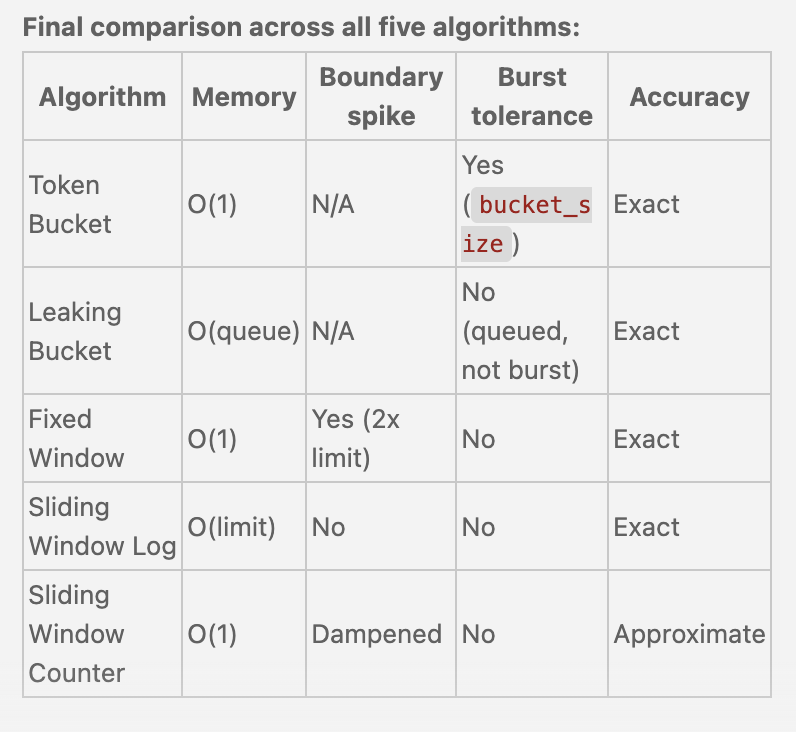

### Rate limiting Headers:
The rate limiter returns the following HTTP headers to clients:
1. X-Ratelimit-Remaining -> the remaining number of allowed requests with in the window.
2. X-Ratelimit-Limit -> It indicates how many calls the client can make per time window.
3. X-Ratelimit-Retry-After -> The number of seconds to wait until you can make the request again without being throttled. 

### Rate Limiter in Distributed environment:
There are two challenges:
1. Race Condition.
2. Synchronization issue.

#### Race Condition

Race condition happen in a highly concurrent environment.
Assume the counter value in Redis is 3. If two requests concurrently read the counter value before either of them writes the value back, each will increment the counter by one and write it back without checking the other thread. Both requests(thread) believe they have a correct counter value 4. However the correct counter value should be 5.

Locks are the most obvious solution for solving the race condition. However locks will significantly slow down the system.

Two Strategies are commonly used to solve the problem:
1. Lua Script
2. Sorted Set data structure in redis.

#### Redis + Lua for Rate Limiting

Every in-memory implementation we wrote uses a `Lock` to prevent race conditions.
In a distributed system with multiple servers, each process has its own lock — they
cannot protect each other. Two servers can simultaneously read `count=4`, both see it
is under the limit, both increment to 5, and two requests slip past the limit.

```
Server A  ──┐
Server B  ──┤──→  Redis (single thread)  →  Lua script runs atomically
Server C  ──┘                                no interleaving possible
```

Redis is single-threaded. A Lua script sent via `EVAL` runs **atomically** —
Redis processes no other command until the script finishes. This is the distributed
equivalent of our `threading.Lock`.

| Concern | In-memory solution | Redis + Lua solution |
|---|---|---|
| Race condition | `threading.Lock` | Lua atomicity via `EVAL` |
| State storage | Python `dict` | Redis keys with TTL |
| Multi-server | Impossible (per-process) | All servers share one Redis |
| Memory cleanup | Manual eviction logic | `EXPIRE` — Redis handles it |

---

##### 1. Fixed Window Counter

The window is encoded in the Redis key itself (e.g. `rate:user-1:1713000`).
When the window expires, the key expires — no explicit reset needed.

```lua
-- KEYS[1] = "rate:{client_id}:{window_timestamp}"
-- ARGV[1] = limit
-- ARGV[2] = window size in seconds

local key    = KEYS[1]
local limit  = tonumber(ARGV[1])
local window = tonumber(ARGV[2])

local count = redis.call('INCR', key)  -- atomic: increment and return new value

if count == 1 then
    -- First request in this window — set the TTL so the key auto-expires
    redis.call('EXPIRE', key, window)
end

if count > limit then
    return 0  -- rejected (429)
end
return 1      -- allowed
```

---

##### 2. Sliding Window Log

Uses a Redis **Sorted Set** (ZSET) where score = timestamp.
`ZREMRANGEBYSCORE` replaces our `_evict()` loop. `ZCARD` replaces `len(log)`.

```lua
-- KEYS[1] = "rate:{client_id}"
-- ARGV[1] = limit
-- ARGV[2] = window size in milliseconds
-- ARGV[3] = now in milliseconds  (passed in by the caller)

local key    = KEYS[1]
local limit  = tonumber(ARGV[1])
local window = tonumber(ARGV[2])
local now    = tonumber(ARGV[3])

-- 1. Evict timestamps outside the rolling window
redis.call('ZREMRANGEBYSCORE', key, '-inf', now - window)

-- 2. Count what remains
local count = redis.call('ZCARD', key)

if count < limit then
    -- score = timestamp, member = timestamp (unique per ms; add random suffix if needed)
    redis.call('ZADD', key, now, now)
    redis.call('PEXPIRE', key, window)  -- auto-cleanup after one window of inactivity
    return 1
end
return 0
```

---

##### 3. Sliding Window Counter

Two keys — one for the current window, one for the previous.
The caller computes `elapsed_fraction` and passes it in as an argument.

```lua
-- KEYS[1] = "rate:{client_id}:{curr_window}"
-- KEYS[2] = "rate:{client_id}:{prev_window}"
-- ARGV[1] = limit
-- ARGV[2] = elapsed_fraction  (how far into the current window: 0.0–1.0)
-- ARGV[3] = window size in seconds

local curr_key         = KEYS[1]
local prev_key         = KEYS[2]
local limit            = tonumber(ARGV[1])
local elapsed_fraction = tonumber(ARGV[2])
local window           = tonumber(ARGV[3])

local prev_count = tonumber(redis.call('GET', prev_key) or 0)
local curr_count = tonumber(redis.call('GET', curr_key) or 0)

-- Weighted rolling estimate (same formula as our Python implementation)
local rolling = prev_count * (1 - elapsed_fraction) + curr_count

if rolling < limit then
    redis.call('INCR', curr_key)
    -- Keep key alive for 2 windows so it can serve as the previous window next cycle
    redis.call('EXPIRE', curr_key, window * 2)
    return 1
end
return 0
```


In [ ]:
"""
How the caller (Python service) invokes each Lua script via redis-py.

redis.register_script() compiles the script once and returns a callable.
redis-py handles the EVAL command and passes KEYS / ARGV automatically.
"""
import time
import math

# import redis
# r = redis.Redis(host="localhost", port=6379, decode_responses=True)

# ---------------------------------------------------------------------------
# 1. Fixed Window Counter
# ---------------------------------------------------------------------------
FIXED_WINDOW_SCRIPT = """
local key    = KEYS[1]
local limit  = tonumber(ARGV[1])
local window = tonumber(ARGV[2])
local count  = redis.call('INCR', key)
if count == 1 then redis.call('EXPIRE', key, window) end
if count > limit then return 0 end
return 1
"""

def fixed_window_allow(client_id: str, limit: int, window: int) -> bool:
    now_window = int(time.time()) // window  # which window slot are we in
    key = f"rate:fw:{client_id}:{now_window}"
    # script = r.register_script(FIXED_WINDOW_SCRIPT)
    # return bool(script(keys=[key], args=[limit, window]))
    print(f"  EVAL fixed_window  key={key}  limit={limit}  window={window}s")


# ---------------------------------------------------------------------------
# 2. Sliding Window Log
# ---------------------------------------------------------------------------
SLIDING_LOG_SCRIPT = """
local key    = KEYS[1]
local limit  = tonumber(ARGV[1])
local window = tonumber(ARGV[2])
local now    = tonumber(ARGV[3])
redis.call('ZREMRANGEBYSCORE', key, '-inf', now - window)
local count = redis.call('ZCARD', key)
if count < limit then
    redis.call('ZADD', key, now, now)
    redis.call('PEXPIRE', key, window)
    return 1
end
return 0
"""

def sliding_log_allow(client_id: str, limit: int, window_ms: int) -> bool:
    key = f"rate:sl:{client_id}"
    now_ms = int(time.time() * 1000)
    # script = r.register_script(SLIDING_LOG_SCRIPT)
    # return bool(script(keys=[key], args=[limit, window_ms, now_ms]))
    print(f"  EVAL sliding_log  key={key}  now_ms={now_ms}  window_ms={window_ms}")


# ---------------------------------------------------------------------------
# 3. Sliding Window Counter
# ---------------------------------------------------------------------------
SLIDING_COUNTER_SCRIPT = """
local curr_key         = KEYS[1]
local prev_key         = KEYS[2]
local limit            = tonumber(ARGV[1])
local elapsed_fraction = tonumber(ARGV[2])
local window           = tonumber(ARGV[3])
local prev_count = tonumber(redis.call('GET', prev_key) or 0)
local curr_count = tonumber(redis.call('GET', curr_key) or 0)
local rolling = prev_count * (1 - elapsed_fraction) + curr_count
if rolling < limit then
    redis.call('INCR', curr_key)
    redis.call('EXPIRE', curr_key, window * 2)
    return 1
end
return 0
"""

def sliding_counter_allow(client_id: str, limit: int, window: int) -> bool:
    now = time.time()
    curr_slot = int(now) // window
    prev_slot = curr_slot - 1
    elapsed_fraction = (now % window) / window

    curr_key = f"rate:sc:{client_id}:{curr_slot}"
    prev_key = f"rate:sc:{client_id}:{prev_slot}"

    # script = r.register_script(SLIDING_COUNTER_SCRIPT)
    # return bool(script(keys=[curr_key, prev_key], args=[limit, elapsed_fraction, window]))
    print(f"  EVAL sliding_counter  curr={curr_key}  prev={prev_key}"
          f"  elapsed={elapsed_fraction:.2f}  limit={limit}")


# ---------------------------------------------------------------------------
# Show the key patterns each algorithm uses
# ---------------------------------------------------------------------------
print("Key patterns per algorithm:")
fixed_window_allow("user-1", limit=10, window=1)
sliding_log_allow("user-1", limit=10, window_ms=1000)
sliding_counter_allow("user-1", limit=10, window=1)


### Sorted Set data structure in Redis for Race Condition

The notebook lists two strategies for solving the race condition. Let's break down why Sorted Set is one of them and how it differs from a plain counter.

---

#### The race condition with a plain counter

With `GET` + `SET`, the race window spans three separate commands:

```
Server A:  GET counter → 4
Server B:  GET counter → 4        ← both read before either writes
Server A:  SET counter = 5   ✅
Server B:  SET counter = 5   ✅   ← should be 6, both snuck through the limit
```

---

#### Why Sorted Set (ZSET) is different

With a ZSET, each request writes its own **unique entry** — there is no read-then-write on a shared value:

```
Server A:  ZADD rate:user-1  score=1713001.123  member="req-uuid-A"  ✅
Server B:  ZADD rate:user-1  score=1713001.124  member="req-uuid-B"  ✅
```

`ZADD` is a single atomic command. Two concurrent requests do not clobber each other — they each append their own slot independently.

---

#### Full flow of ZSET-based Sliding Window Log

```
Request arrives
      ↓
ZREMRANGEBYSCORE key -inf (now - window)   ← evict expired entries  (atomic)
      ↓
ZCARD key                                  ← count active entries   (atomic)
      ↓
count < limit?
  YES → ZADD key score=now member=uuid     ← each request owns its own slot
  NO  → reject 429
```

---

#### Why each member must be unique

If two requests arrive at the same millisecond and both use `member=timestamp`,
the second `ZADD` silently **overwrites** the first — one request disappears from the set.
Using a UUID per request prevents this:

```python
import uuid, time
member = f"{int(time.time() * 1000)}-{uuid.uuid4()}"  # unique even at same millisecond
```

---

#### The remaining race window — why Lua is still needed

`ZREMRANGEBYSCORE` → `ZCARD` → `ZADD` are three separate commands.
Without Lua, two servers can both pass the `ZCARD` check before either does `ZADD`:

```
Server A:  ZCARD → 4   (under limit 5)
Server B:  ZCARD → 4   (under limit 5)   ← both read, neither has written yet
Server A:  ZADD  → set has 5 entries
Server B:  ZADD  → set has 6 entries     ← over limit, slipped through
```

---

#### ZSET and Lua work together — not as alternatives

| Strategy | What it solves | What it does NOT solve |
|---|---|---|
| Sorted Set | Each request owns its slot — no shared counter to corrupt | The check → write sequence is still 3 separate commands |
| Lua script | Wraps all 3 commands into one atomic operation | Does not help if members are not unique |
| **Both together** | Fully correct under any concurrency | — |

The plain counter approach needs Lua because the data model itself is fragile (shared mutable integer).
The ZSET approach is safer by design (immutable per-request slots), but Lua is still required to make the check-and-insert atomic under strict correctness requirements.


### Synchronization Issue in Distributed Systems

Race condition is about two threads fighting over the **same counter**.
Synchronization is a different problem: multiple rate limiter nodes each have
**their own counter** and have no idea what the others are counting.

---

#### The problem

If you run 3 rate limiter nodes with `limit=5` and no shared state:

```
Client sends 12 requests, load-balanced across 3 nodes

Node 1:  sees 4 requests  → allows all 4  (counter=4, under limit 5)
Node 2:  sees 4 requests  → allows all 4  (counter=4, under limit 5)
Node 3:  sees 4 requests  → allows all 4  (counter=4, under limit 5)

Total passed: 12   ← should have been 5
```

Each node thinks it is within the limit. Nobody is wrong locally.
The system is wrong globally.

---

#### Solution 1 — Sticky Sessions

Route every request from the same client to the same node using
consistent hashing or a session cookie.

```
Client "user-1"  ──→  always hits Node 2
Client "user-2"  ──→  always hits Node 1
Client "user-3"  ──→  always hits Node 3
```

Node 2 now sees all of user-1's requests and can enforce the limit correctly.

**Drawback:** Uneven load distribution. If user-1 sends 10x more traffic,
Node 2 becomes a hotspot while Node 1 sits idle. Also fails when a node
goes down — sticky mapping breaks and requests flood a new node with a cold counter.

---

#### Solution 2 — Centralised Data Store (Redis)

All nodes read and write to a single shared Redis instance.
No local counter — Redis is the only source of truth.

```
                    ┌──────────┐
Node 1  ──INCR──→  │          │
Node 2  ──INCR──→  │  Redis   │  ← single counter for user-1
Node 3  ──INCR──→  │          │
                    └──────────┘
```

Every `INCR` is atomic in Redis, so all nodes see the same count.
12 requests → Redis counter reaches 5 → nodes 6–12 are rejected regardless
of which node handles them.

**This is why every production Lua script we wrote uses `KEYS[1]` as a shared
Redis key — the key is the synchronisation point across all nodes.**

---

#### Trade-offs

| | Sticky Sessions | Centralised Redis |
|---|---|---|
| Accuracy | Exact (within one node) | Exact (shared counter) |
| Load distribution | Uneven (hotspots) | Even (any node, any request) |
| Node failure | Counter lost, cold restart | Redis survives node failures |
| Latency | No network hop | One Redis round-trip per request |
| Single point of failure | No | Yes — mitigated by Redis Cluster / Sentinel |

---

#### Redis Cluster — removing the single point of failure

A single Redis node is itself a bottleneck and a SPOF.
Redis Cluster shards keys across multiple nodes and replicates each shard:

```
rate:user-1  ──→  Shard A  (primary + replica)
rate:user-2  ──→  Shard B  (primary + replica)
rate:user-3  ──→  Shard C  (primary + replica)
```

If Shard A's primary dies, its replica is promoted automatically.
The rate limiter keeps working with no manual intervention.

---

#### Summary

```
Problem                         Solution
──────────────────────────────────────────────────────
Each node has its own counter   →  Centralised Redis (shared key)
Redis is a single point         →  Redis Cluster / Sentinel
Two requests race on one key    →  Lua script (atomic EVAL)
ZSET entries collide at same ms →  UUID suffix on member name
```

All four problems are distinct layers — each solution addresses exactly one layer.


### Performance Optimization

We can do performance optimization based on the two areas:
1. First, multi-data center setup is crucial for rate limiter because latency is high for users located far away from data center. Most cloud service providers build many edge server locations around the world.
2. Synchronise data with eventual consistency model.

### Monitoring

After the rate limiter is put in place, it is important to gather analytics data to check whether the rate limiter is effective. We want to make sure:
-> The rate limiter algorithm is effective.
-> The rate limiter rules are effective.

If the rate limiter rules are too strict, many valid request are dropped. In this case we need to relax the rules a little bit. 

#### Important Points to make Note of:
1. Rate limiting at different level. We have covered the rate limiting at application leyer, we can rate limit by IP address.
2. Avoid being rate limited. Design the client with best practices:
    1. Use client cache to avoid making frequent API calls.
    2. Understand the limit and do not send too many requests in a short time frame.
    3. Include code to catch exception or errors so your client can gracefully recover from exception.
    4. Add sufficient back off time to retry logic.
3. When you need to make continues calls to Redis, you should be maintaining the connection pool,so that it can skip the TCP Handshake overhead, which is needed for every request to redis. Thius reduce the overall time taken.
4. Whenever there are rules got changed, You should replicate the same in API Gateway, firstly you should have push based update from services like zookeeper, etcd. Or we can have a create persistent TCP connection with the Zookeeper from API Gateway, which will check for updates. Rules are stored in API Gateway.


### What if the rate limit Fails?
There are two options:
1. Fail-open: Where everything will pass without rate limiting.
2. Fail-close: Nothing will pass until the rate limiting is back.
3. Fallback to Fixed window which you have it in APi gateway